<div style="background-color:#000047; padding: 30px; border-radius: 10px; color: white; text-align: center;">
    <img src='Figures/alinco_white_text.png' style="height: 100px; margin-bottom: 10px;"/>
    <h1>Modulo 1: Introducción a TensorFlow 2.0</h1>
    <h3>Aprendizaje Automático Avanzado</h3>
</div>


### Historia de TensorFlow

Hace algunos años, el aprendizaje profundo (*deep learning*) comenzó a superar a todos los demás algoritmos de aprendizaje automático cuando se le entrenaba con grandes cantidades de datos. Google observó que podía usar estas redes neuronales profundas para mejorar muchos de sus servicios:

- **Gmail** (filtrado inteligente de correo)
- **Google Photos** (reconocimiento y clasificación de imágenes)
- **Motor de búsqueda de Google** (ranking y comprensión de consultas)

Para lograrlo, Google construyó un *framework* llamado **TensorFlow** que permite a investigadores y desarrolladores trabajar de forma conjunta sobre un mismo modelo de IA. Una vez desarrollado y escalado, el modelo puede ser utilizado por muchas personas.

TensorFlow se hizo público por primera vez a finales de **2015**, y su primera versión estable apareció en **2017**. Es un proyecto de **código abierto** bajo licencia Apache 2.0. En **2019** se lanzó **TensorFlow 2.0**, que simplificó enormemente la API adoptando la ejecución *eager* (inmediata) por defecto e integrando **Keras** como su API oficial de alto nivel.

### Arquitectura de TensorFlow

El flujo de trabajo con TensorFlow se organiza en tres etapas:

1. **Preprocesamiento de los datos** — limpiar, normalizar y darles la forma adecuada.
2. **Construcción del modelo** — definir la arquitectura (capas, operaciones, parámetros).
3. **Entrenamiento y evaluación del modelo** — ajustar los pesos y medir el desempeño.

Se llama *TensorFlow* porque toma como entrada matrices multidimensionales, también conocidas como **tensores**, y define un **flujo (flow)** de operaciones sobre ellos. Puede construirse una especie de diagrama de flujo de operaciones (llamado **grafo** o *Graph*): los datos entran por un extremo, fluyen a través de una secuencia de operaciones y salen por el otro extremo como resultado.

### Componentes de TensorFlow

#### Tensor

El nombre *TensorFlow* proviene directamente de su estructura de datos principal: el **Tensor**. En TensorFlow, todos los cálculos involucran tensores. Un tensor es un arreglo (vector o matriz) de **n dimensiones** que representa cualquier tipo de dato. Todos los valores de un tensor comparten un mismo tipo de dato (*dtype*) y tienen una forma (*shape*) conocida —o parcialmente conocida—. La **forma** describe la dimensionalidad del arreglo.

Un tensor puede originarse a partir de los datos de entrada o como resultado de un cálculo.

#### Grafo (Graph)

Aunque TensorFlow 2.0 ejecuta las operaciones de forma inmediata (*eager execution*), internamente aún puede aprovechar un **grafo de cómputo** (por ejemplo, con `@tf.function`) para optimizar el entrenamiento. Un grafo recopila y describe todos los cálculos realizados. Sus ventajas son:

- Puede ejecutarse en múltiples **CPU** o **GPU**, e incluso en dispositivos **móviles** (TensorFlow Lite).
- Es **portable**: el grafo puede guardarse para ejecutarse más adelante o en otro dispositivo.
- Todos los cálculos se realizan conectando tensores entre sí.
- Cada **nodo** representa una operación matemática y produce una salida; los **bordes** representan los tensores que fluyen entre los nodos (relaciones entrada/salida).

### Algoritmos de alto nivel soportados por TensorFlow (API Estimator)

TensorFlow incluye estimadores predefinidos (`tf.estimator`) para tareas comunes:

- Regresión lineal: `tf.estimator.LinearRegressor`
- Clasificación lineal: `tf.estimator.LinearClassifier`
- Clasificación con redes profundas: `tf.estimator.DNNClassifier`
- Modelos *wide & deep*: `tf.estimator.DNNLinearCombinedClassifier`
- Regresión con árboles potenciados: `tf.estimator.BoostedTreesRegressor`
- Clasificación con árboles potenciados: `tf.estimator.BoostedTreesClassifier`

> **Nota:** En TensorFlow 2.x el enfoque recomendado para construir modelos es la API **Keras** (`tf.keras`), que veremos más adelante. Los estimadores siguen disponibles pero se usan cada vez menos.


## Tipos de tensores

En TensorFlow, todos los cálculos pasan a través de uno o más tensores. Un tensor es un objeto con tres propiedades fundamentales:

- Una **etiqueta** o nombre (*name*)
- Una **forma** o dimensión (*shape*)
- Un **tipo de dato** (*dtype*)

Cada operación que realices con TensorFlow implica la manipulación de tensores. Los principales tipos de tensores que puedes crear son:

- `tf.constant` — un tensor **constante**, cuyo valor no cambia.
- `tf.Variable` — un tensor **variable**, cuyo valor **sí** puede modificarse (por ejemplo, los pesos de un modelo).
- `tf.SparseTensor` — un tensor **disperso**, eficiente cuando la mayoría de los valores son cero.
- `tf.RaggedTensor` — un tensor **irregular**, con filas de diferente longitud.

> **Nota histórica:** En TensorFlow 1.x también existía `tf.placeholder`, que servía para alimentar datos dentro de una *sesión* (`tf.Session`). En **TensorFlow 2.0 los placeholders y las sesiones fueron eliminados**, ya que la ejecución *eager* permite evaluar las operaciones directamente.


## TensorFlow 2.0

### Instalar TensorFlow 2.0

Ejecuta el siguiente comando en una celda de código para instalar TensorFlow (elimina el `#` para usarlo). Se recomienda una versión reciente de la rama 2.x:

```bash
!pip install tensorflow
```

> Si trabajas con un entorno gestionado (conda/venv), instala TensorFlow dentro de ese entorno. Puedes fijar una versión concreta con, por ejemplo, `!pip install tensorflow==2.15.0`.


In [1]:
import tensorflow as tf

In [2]:
import numpy as np

In [3]:
tf.__version__

'2.21.0'

### Crear un tensor de dimensión n
Comienza con la creación de un tensor con una dimensión, es decir, un escalar.

Para crear un tensor, puede usar tf.constant ()

```python
tf.constant(value, dtype=None, shape=None, name="Const")
```

**Argumentos:**

- `value`: el valor (escalar, lista o arreglo de n dimensiones) con el que se define el tensor. **Obligatorio.**
- `dtype`: define el tipo de dato del tensor. **Opcional.** Algunos ejemplos:
    - `tf.string`: cadenas de texto
    - `tf.float32`: números de punto flotante
    - `tf.int16`: números enteros
- `shape`: forma opcional que fuerza las dimensiones del tensor.
- `name`: nombre del tensor. **Opcional.** Por defecto es `"Const"`.


### Tensor de dimensión 0

In [4]:
## rank 0
# Default name
r1 = tf.constant(1,tf.int16)
print(r1)

tf.Tensor(1, shape=(), dtype=int16)


In [5]:
# Named my_scalar
r1 = tf.constant(1,tf.int16, name= "mi_escalar")
print(r1)

tf.Tensor(1, shape=(), dtype=int16)


Cada tensor se muestra con el nombre del tensor. Cada objeto tensor se define con una etiqueta única (nombre), una dimensión (forma) y un tipo de datos (dtype).

Puede definir un tensor con valores decimales o con una cadena cambiando el tipo de datos.

In [6]:
# Decimal
r1_decimal = tf.constant(1.2343, tf.float32)
print(r1_decimal)

tf.Tensor(1.2343, shape=(), dtype=float32)


In [7]:
# String
r1_string = tf.constant("hola", tf.string)
print(r1_string)

tf.Tensor(b'hola', shape=(), dtype=string)


In [8]:
# El "rango" (rank) es el número de dimensiones del tensor.
# Un escalar tiene rango 0.
print("Valor:", r1.numpy())
print("Rango:", tf.rank(r1).numpy())

Valor: 1
Rango: 0


Se puede crear un tensor de la dimensión 1 de la siguiente manera:

In [9]:
## Rank 1
r1_vector = tf.constant([1,2,3,4], tf.int16)
print(r1_vector)

tf.Tensor([1 2 3 4], shape=(4,), dtype=int16)


In [10]:
r1_bool = tf.constant([True,False,True], tf.bool)
print(r1_bool)

tf.Tensor([ True False  True], shape=(3,), dtype=bool)


In [11]:
# Un vector (rank 1) tiene una sola dimensión
print("Forma del vector:", r1_vector.shape)
print("Rango:", tf.rank(r1_vector).numpy())

Forma del vector: (4,)
Rango: 1


Puede observar que la forma sólo está compuesta por 1 columna.

Para crear una matriz de 2 dimensiones, debe cerrar los corchetes después de cada fila. Echa un vistazo a los ejemplos siguientes

In [12]:
## Rank 2
r2_matrix = tf.constant([[1,2],[3,4]], tf.int16)
print(r2_matrix)

tf.Tensor(
[[1 2]
 [3 4]], shape=(2, 2), dtype=int16)


#### Forma del tensor
Cuando se imprime el tensor, TensorFlow adivina la forma. Sin embargo, puede obtener la forma del tensor con la propiedad shape.

A continuación, se construye una matriz llena con un número del 10 al 15 y se comprueba la forma de m_shape

In [13]:
# Shape of tensor
m_shape=tf.constant([[10,11],
                    [12,13],
                    [14,15]])
print(m_shape)

tf.Tensor(
[[10 11]
 [12 13]
 [14 15]], shape=(3, 2), dtype=int32)


In [14]:
m_shape.shape

TensorShape([3, 2])

La matriz tiene 3 filas y 2 columnas.

TensorFlow tiene comandos útiles para crear un vector o una matriz llena con 0 o 1. Por ejemplo, si desea crear un tensor 1-D con una forma específica de 10, rellenado con 0, puede ejecutar el siguiente código:

In [15]:
# Create a vector of 0
print(tf.zeros(10))

tf.Tensor([0. 0. 0. 0. 0. 0. 0. 0. 0. 0.], shape=(10,), dtype=float32)


La propiedad también funciona para matriz. Aquí, crea una matriz 10×10 llena de 1

In [16]:
# Create a vector of 1
print(tf.ones(10))

tf.Tensor([1. 1. 1. 1. 1. 1. 1. 1. 1. 1.], shape=(10,), dtype=float32)


In [17]:
print(tf.ones([10,10]))

tf.Tensor(
[[1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]], shape=(10, 10), dtype=float32)


Puede usar la forma de una matriz dada para hacer un vector de unos. La matriz m_shape es una dimensión 3×2. Puede crear un tensor con 3 filas rellenadas por uno con el siguiente código:

In [18]:
# Create a vector of ones with the same number of rows as m_shape
m_shape.shape

TensorShape([3, 2])

In [19]:
print(tf.ones(m_shape.shape[0]))

tf.Tensor([1. 1. 1.], shape=(3,), dtype=float32)


In [20]:
print(tf.ones(m_shape.shape[1]))

tf.Tensor([1. 1.], shape=(2,), dtype=float32)


In [21]:
print(tf.ones([m_shape.shape[0], m_shape.shape[1]]))

tf.Tensor(
[[1. 1.]
 [1. 1.]
 [1. 1.]], shape=(3, 2), dtype=float32)


In [22]:
[m_shape.shape[0], m_shape.shape[1]]

[3, 2]

Si pasa el valor 1 en el corchete, puede construir un vector de unos igual al número de columnas en la matriz m_shape.

In [23]:
# Create a vector of ones with the same number of column as m_shape
print(tf.ones(m_shape.shape))

tf.Tensor(
[[1. 1.]
 [1. 1.]
 [1. 1.]], shape=(3, 2), dtype=float32)


Finalmente, puede crear una matriz 3×2 con solo una

### Tipo de datos
La segunda propiedad de un tensor es el tipo de datos. Un tensor solo puede tener un tipo de datos a la vez. Un tensor solo puede tener un tipo de datos. Puede devolver el tipo con la propiedad dtype.

In [24]:
m_shape.dtype

tf.int32

En algunas ocasiones, desea cambiar el tipo de datos. En TensorFlow, es posible con el método tf.cast.

###### Ejemplo

A continuación, un tensor flotante se convierte en entero utilizando el método de conversión.

In [25]:
# Change type of data
type_float = tf.constant(3.1416, tf.float32)
type_int = tf.cast(type_float, dtype=tf.int32)


In [26]:
type_float.dtype

tf.float32

In [27]:
type_int.dtype

tf.int32

In [28]:
type_int

<tf.Tensor: shape=(), dtype=int32, numpy=3>

TensorFlow elige automáticamente el tipo de datos cuando el argumento no se especifica durante la creación del tensor. TensorFlow adivinará cuáles son los tipos de datos más probables. Por ejemplo, si pasa un texto, adivinará que es una cadena y la convertirá en cadena.

#### Creando operador
##### Algunos operadores TensorFlow útiles
Sabes cómo crear un tensor con TensorFlow. Es hora de aprender a realizar operaciones matemáticas.

TensorFlow contiene todas las operaciones básicas. Puedes comenzar con uno simple. Va a utilizar el método TensorFlow para calcular el cuadrado de un número. Esta operación es sencilla porque solo se requiere un argumento para construir el tensor.

El cuadrado de un número se construye con tf.sqrt (x) con x como un número flotante.

In [29]:
x = tf.constant([2.0], dtype=tf.float32)


In [30]:
tf.sqrt(x)

<tf.Tensor: shape=(1,), dtype=float32, numpy=array([1.4142135], dtype=float32)>

**Nota:** en TensorFlow 2.0 la salida ya muestra el **resultado** de la operación (gracias a la ejecución *eager*), a diferencia de TensorFlow 1.x, donde `print` mostraba únicamente la definición del tensor y era necesario ejecutar una *sesión* para obtener el valor.

A continuación se presenta una lista de operaciones de uso común. La idea es la misma en todas: cada operación requiere uno o más argumentos.

- `tf.add(a, b)` — suma
- `tf.subtract(a, b)` — resta
- `tf.multiply(a, b)` — multiplicación elemento a elemento
- `tf.divide(a, b)` — división
- `tf.pow(a, b)` — potencia
- `tf.exp(a)` — exponencial
- `tf.sqrt(a)` — raíz cuadrada
- `tf.matmul(a, b)` — producto matricial

In [31]:
# Add
tensor_a = tf.constant([[1,2]], dtype=tf.int32)
tensor_b = tf.constant([[4,3]], dtype=tf.int32)

tensor_add = tf.add(tensor_a,tensor_b)


In [32]:
tensor_add

<tf.Tensor: shape=(1, 2), dtype=int32, numpy=array([[5, 5]], dtype=int32)>

Explicación de código

Cree dos tensores:

un tensor con 1 y 2
un tensor con 3 y 4
Suma ambos tensores.

Aviso: que ambos tensores deben tener la misma forma. Puede ejecutar una multiplicación sobre los dos tensores.

In [33]:
# Multiply
tensor_mul = tf.multiply(tensor_a,tensor_b)
tensor_mul

<tf.Tensor: shape=(1, 2), dtype=int32, numpy=array([[4, 6]], dtype=int32)>

In [34]:
help(np.random.randint)

Help on method randint in module numpy.random:

randint(low, high=None, size=None, dtype=<class 'int'>) method of numpy.random.mtrand.RandomState instance
    randint(low, high=None, size=None, dtype=int)
    
    Return random integers from `low` (inclusive) to `high` (exclusive).
    
    Return random integers from the "discrete uniform" distribution of
    the specified dtype in the "half-open" interval [`low`, `high`). If
    `high` is None (the default), then results are from [0, `low`).
    
    .. note::
        New code should use the `~numpy.random.Generator.integers`
        method of a `~numpy.random.Generator` instance instead;
        please see the :ref:`random-quick-start`.
    
    Parameters
    ----------
    low : int or array-like of ints
        Lowest (signed) integers to be drawn from the distribution (unless
        ``high=None``, in which case this parameter is one above the
        *highest* such integer).
    high : int or array-like of ints, optional
      

In [35]:
# Ejercicio: crear dos tensores 5x5 con enteros aleatorios,
# y calcular su suma y su multiplicación (elemento a elemento).
tensor_x = tf.constant(np.random.randint(10, size=(5, 5)))
tensor_y = tf.constant(np.random.randint(10, size=(5, 5)))
print("Tensor X:\n", tensor_x.numpy())
print("\nTensor Y:\n", tensor_y.numpy())

Tensor X:
 [[9 6 1 9 8]
 [9 8 5 5 8]
 [8 0 4 1 9]
 [2 6 9 5 3]
 [3 6 7 4 0]]

Tensor Y:
 [[1 7 7 4 0]
 [2 7 9 0 2]
 [1 2 8 3 4]
 [2 9 1 1 7]
 [7 4 4 4 9]]


In [36]:
# Suma de los dos tensores
tf.add(tensor_x,tensor_y)

<tf.Tensor: shape=(5, 5), dtype=int32, numpy=
array([[10, 13,  8, 13,  8],
       [11, 15, 14,  5, 10],
       [ 9,  2, 12,  4, 13],
       [ 4, 15, 10,  6, 10],
       [10, 10, 11,  8,  9]], dtype=int32)>

In [37]:
# Multiplicación elemento a elemento de los dos tensores
tf.multiply(tensor_x,tensor_y)


<tf.Tensor: shape=(5, 5), dtype=int32, numpy=
array([[ 9, 42,  7, 36,  0],
       [18, 56, 45,  0, 16],
       [ 8,  0, 32,  3, 36],
       [ 4, 54,  9,  5, 21],
       [21, 24, 28, 16,  0]], dtype=int32)>

### Constantes

#### Definir una constante

In [38]:
# Definir una constante en TensorFlow 2.0
tensor_20=tf.constant([[2,3],[3,6]])
tensor_20

<tf.Tensor: shape=(2, 2), dtype=int32, numpy=
array([[2, 3],
       [3, 6]], dtype=int32)>

In [39]:
# Consultar el tipo de dato de la constante
tensor_20.dtype

tf.int32

In [40]:
# Obtener el tamaño de un tensor
tensor_20.shape

TensorShape([2, 2])

#### Consultar los valores de una constante

In [41]:
# Obtener los valores directamente desde una constante de TensorFlow con numpy, sin necesidad de una session
tensor_20.numpy()

array([[2, 3],
       [3, 6]], dtype=int32)

In [42]:
# Podemos convertir un array de numpy a un tensor de TensorFlow directamente
a = np.array([[2,3],[5,8]])
a

array([[2, 3],
       [5, 8]])

In [43]:
tensor3=tf.constant(a)

In [44]:
tensor3

<tf.Tensor: shape=(2, 2), dtype=int64, numpy=
array([[2, 3],
       [5, 8]])>

### Variables

#### Definir una variable

In [45]:
tf2_variable = tf.Variable([[1.,2.,3.],[4.,5.,6.]])
tf2_variable

<tf.Variable 'Variable:0' shape=(2, 3) dtype=float32, numpy=
array([[1., 2., 3.],
       [4., 5., 6.]], dtype=float32)>

#### Consultar los valores de una variable

In [46]:
tf2_variable.numpy()

array([[1., 2., 3.],
       [4., 5., 6.]], dtype=float32)

#### Cambiar un valor especifico de una variable

In [47]:
tf2_variable[0,2].numpy()

np.float32(3.0)

In [48]:
tf2_variable[0,2].assign(100)


<tf.Variable 'UnreadVariable' shape=(2, 3) dtype=float32, numpy=
array([[  1.,   2., 100.],
       [  4.,   5.,   6.]], dtype=float32)>

### Constantes vs Variables

En TensorFlow, las diferencias entre constantes y variables son que cuando se declara una constante, su valor no se puede cambiar en el futuro (también se inicialización debe ser un valor, no una operación).

Sin embargo, cuando declara una Variable, puede cambiar su valor en el futuro con el método tf.assign()

### Operaciones con tensores

In [49]:
tensor = tf.constant([[1,2],[3,4]])
tensor

<tf.Tensor: shape=(2, 2), dtype=int32, numpy=
array([[1, 2],
       [3, 4]], dtype=int32)>

#### Sumar un escalar a un tensor

In [50]:
tensor +2

<tf.Tensor: shape=(2, 2), dtype=int32, numpy=
array([[3, 4],
       [5, 6]], dtype=int32)>

#### Multiplicar un escalar por un tensor

In [51]:
tensor*5

<tf.Tensor: shape=(2, 2), dtype=int32, numpy=
array([[ 5, 10],
       [15, 20]], dtype=int32)>

#### Utilizar funciones de Numpy sobre tensores de TensorFlow

In [52]:
# Obtener los cuadrados de todos los números de un tensor de TensorFlow
np.square(tensor)

array([[ 1,  4],
       [ 9, 16]], dtype=int32)

In [53]:
# Obtener la raíz cuadrada de todos los números de un tensor de TensorFlow
np.sqrt(tensor)

array([[1.        , 1.41421356],
       [1.73205081, 2.        ]])

#### Producto escalar entre dos tensores

In [54]:
np.dot(tensor,tensor_20) 

array([[ 8, 15],
       [18, 33]], dtype=int32)

### Strings en TensorFlow 2.0

In [55]:
tf_string = tf.constant('Tensorflow')

In [56]:
tf_string

<tf.Tensor: shape=(), dtype=string, numpy=b'Tensorflow'>

#### Operaciones simples con strings

In [57]:
tf.strings.length(tf_string)

<tf.Tensor: shape=(), dtype=int32, numpy=10>

In [58]:
tf.strings.unicode_decode(tf_string, "UTF8")

<tf.Tensor: shape=(10,), dtype=int32, numpy=array([ 84, 101, 110, 115, 111, 114, 102, 108, 111, 119], dtype=int32)>

#### Almacenar arrays de strings

In [59]:
tf_str_array=tf.constant(["hola","como","estás"])

In [60]:
# Iterar sobre un array de strings en TF
for string in tf_str_array:
    print(string)

tf.Tensor(b'hola', shape=(), dtype=string)
tf.Tensor(b'como', shape=(), dtype=string)
tf.Tensor(b'est\xc3\xa1s', shape=(), dtype=string)


In [61]:
# Convertir cada string a mayúsculas
tf.strings.upper(tf_str_array)

<tf.Tensor: shape=(3,), dtype=string, numpy=array([b'HOLA', b'COMO', b'EST\xc3\xa1S'], dtype=object)>

### Cambiar la forma de un tensor (reshape)

Una operación muy común es reorganizar los elementos de un tensor en una nueva forma sin alterar sus datos. Para ello se usa `tf.reshape`. El número total de elementos debe conservarse.

In [62]:
# Vector de 12 elementos
vector = tf.constant(np.arange(12))
print("Original:", vector.numpy(), "-> forma", vector.shape)

# Reorganizar como matriz 3x4
matriz = tf.reshape(vector, (3, 4))
print("\nReshape a 3x4:\n", matriz.numpy())

# Usar -1 para inferir automáticamente una dimensión (aquí, 2 filas)
auto = tf.reshape(vector, (2, -1))
print("\nReshape a (2, -1):\n", auto.numpy())

Original: [ 0  1  2  3  4  5  6  7  8  9 10 11] -> forma (12,)

Reshape a 3x4:
 [[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]

Reshape a (2, -1):
 [[ 0  1  2  3  4  5]
 [ 6  7  8  9 10 11]]


### Broadcasting

El *broadcasting* permite operar entre tensores de formas distintas pero compatibles: TensorFlow "expande" automáticamente la dimensión más pequeña para que coincidan. Es la misma regla que utiliza NumPy.

In [63]:
# Una matriz 3x3 se suma con un vector de 3 elementos (se aplica a cada fila)
matriz = tf.constant([[1, 2, 3],
                      [4, 5, 6],
                      [7, 8, 9]])
vector_fila = tf.constant([10, 20, 30])

print("Matriz + vector (broadcasting):\n", (matriz + vector_fila).numpy())

Matriz + vector (broadcasting):
 [[11 22 33]
 [14 25 36]
 [17 28 39]]


### Información del entorno y dispositivos (CPU / GPU)

TensorFlow puede ejecutar los cálculos en CPU o GPU. El siguiente bloque muestra la versión instalada, si la ejecución *eager* está activa y qué GPUs detecta TensorFlow. Contar con una GPU acelera enormemente el entrenamiento de redes profundas.

In [64]:
print("Versión de TensorFlow:", tf.__version__)
print("¿Ejecución eager activa?:", tf.executing_eagerly())
print("GPUs disponibles:", tf.config.list_physical_devices("GPU"))
print("CPUs disponibles:", tf.config.list_physical_devices("CPU"))

Versión de TensorFlow: 2.21.0
¿Ejecución eager activa?: True
GPUs disponibles: []
CPUs disponibles: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


## Algunos ejemplos con TensorFlow 2.0


#### 1. Operaciones y producto matricial

Dadas las matrices:

$$A = \begin{bmatrix} 1 & 2 \\ 3 & 4 \end{bmatrix}, \qquad B = \begin{bmatrix} 5 & 6 \\ 7 & 8 \end{bmatrix}$$

1. Calcula la **suma** elemento a elemento con `tf.add`.
2. Calcula la **multiplicación elemento a elemento** con `tf.multiply`.
3. Calcula el **producto matricial** $A \times B$ con `tf.matmul` y explica por qué el resultado es distinto al del punto 2.

In [66]:
# Solución Ejercicio 2
# tf.multiply opera posición por posición; tf.matmul realiza el producto
A = tf.constant([[1,2],[3,4]])
B = tf.constant([[5,6],[7,8]])

tf.add(A,B)


<tf.Tensor: shape=(2, 2), dtype=int32, numpy=
array([[ 6,  8],
       [10, 12]], dtype=int32)>

In [67]:
tf.multiply(A,B)

<tf.Tensor: shape=(2, 2), dtype=int32, numpy=
array([[ 5, 12],
       [21, 32]], dtype=int32)>

In [68]:
tf.matmul(A,B)

<tf.Tensor: shape=(2, 2), dtype=int32, numpy=
array([[19, 22],
       [43, 50]], dtype=int32)>

#### 2. Filtro de convolución (*blur*) con TensorFlow

Una **imagen** puede verse como un tensor. Una imagen en escala de grises es un tensor de forma $(H, W)$ y una imagen a color es $(H, W, 3)$. Muchas operaciones de procesamiento de imágenes —y el corazón de las **redes neuronales convolucionales (CNN)**— se basan en la **convolución 2D**.

##### ¿Qué es una convolución?

Se hace **deslizar** una pequeña matriz llamada **kernel** (o *filtro*) $K$ de tamaño $k_h \times k_w$ sobre la imagen $I$. En cada posición se calcula la suma ponderada de los píxeles vecinos. Formalmente, la convolución en el píxel $(x, y)$ es:

$$
(I * K)(x, y) = \sum_{i=-a}^{a} \sum_{j=-b}^{b} K(i, j)\; I(x - i,\; y - j)
$$

donde $a = \lfloor k_h/2 \rfloor$ y $b = \lfloor k_w/2 \rfloor$. El resultado en cada píxel depende de su vecindario, definido por el kernel.

##### Kernels de desenfoque (*blur*)

**1) Desenfoque de caja (*box blur*):** promedia todos los vecinos por igual. Para un kernel de $3 \times 3$:

$$
K_{\text{box}} = \frac{1}{9}
\begin{bmatrix}
1 & 1 & 1 \\
1 & 1 & 1 \\
1 & 1 & 1
\end{bmatrix}
$$

El factor $\tfrac{1}{9}$ **normaliza** el kernel (sus valores suman 1) para que el brillo total de la imagen se conserve.

**2) Desenfoque gaussiano (*Gaussian blur*):**  da más peso al píxel central y menos a los lejanos, produciendo un suavizado más natural. Cada valor del kernel se obtiene de la función gaussiana 2D:

$$
G(i, j) = \frac{1}{2\pi\sigma^{2}}\, e^{-\dfrac{i^{2} + j^{2}}{2\sigma^{2}}}
$$

y luego se normaliza dividiendo entre la suma de todos sus elementos.

### La operación en TensorFlow

TensorFlow implementa la convolución con `tf.nn.conv2d`, que espera:

- **Entrada** con forma `[batch, alto, ancho, canales]`.
- **Filtro** con forma `[k_h, k_w, canales_entrada, canales_salida]`.
- `strides`: el paso del desplazamiento (aquí `1` en cada dirección).
- `padding`: `"SAME"` conserva el tamaño de la imagen; `"VALID"` no añade relleno.


#### Definimos los kernels

Construimos los dos filtros de desenfoque como tensores. Notar que ambos **suman 1**, condición para que el desenfoque no oscurezca ni aclare la imagen.

In [70]:
# Kernel de caja (box blur) 5x5: todos los pesos iguales, normalizados
size = 5
box_kernel = np.ones((size,size), dtype=np.float32)/(size*size)

# Kernel gaussiano a partir de la ecuación G(i,j)
def gaussian_kernel(size, sigma):
    ax = np.arange(-(size//2),(size//2))
    xx, yy = np.meshgrid(ax,ax)
    k = np.exp(-(xx**2 + yy**2)/(2*sigma**2))
    return (k/k.sum()).astype(np.float32)
    
    

In [72]:
gauss_kernel = gaussian_kernel(size, sigma = 1.5)
gauss_kernel

array([[0.01862266, 0.03627199, 0.04529823, 0.03627199],
       [0.03627199, 0.07064819, 0.0882289 , 0.07064819],
       [0.04529823, 0.0882289 , 0.11018457, 0.0882289 ],
       [0.03627199, 0.07064819, 0.0882289 , 0.07064819]], dtype=float32)

##### Crear una imagen de ejemplo

Generamos una imagen sintética en escala de grises con formas geométricas y **ruido** (*salt & pepper*), para que el efecto del desenfoque sea claramente visible.

In [73]:
# Construir una imagen sintética 128x128 en escala de grises (valores 0-255)
H = W = 128
img = np.full((H, W), 255.0, dtype=np.float32)

# Rectángulo negro
img[20:55, 25:95] = 0
# Círculo negro
yy, xx = np.mgrid[0:H, 0:W]
img[(xx - 90) ** 2 + (yy - 95) ** 2 < 22 ** 2] = 0
# Franja gris
img[70:80, :] = 128

# Ruido salt & pepper
rng = np.random.default_rng(0)
noise = rng.random((H, W))
img[noise < 0.04] = 0      # pimienta
img[noise > 0.96] = 255    # sal

print("Forma de la imagen:", img.shape, "| dtype:", img.dtype)
print("Valor mínimo:", img.min(), "| máximo:", img.max())

Forma de la imagen: (128, 128) | dtype: float32
Valor mínimo: 0.0 | máximo: 255.0


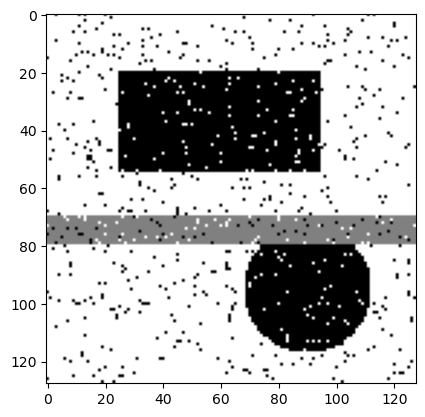

In [75]:
import matplotlib.pyplot as plt
plt.imshow(img, cmap='grey')

##### Aplicar la convolución con `tf.nn.conv2d`

Preparamos la imagen con la forma `[batch, alto, ancho, canales]` y cada kernel con la forma `[k_h, k_w, canales_entrada, canales_salida]`, y aplicamos `tf.nn.conv2d`.

In [77]:
# Imagen -> tensor [batch, alto, ancho, canales]
img_tensor = tf.constant(img.reshape(1,H,W,1))
img_tensor


<tf.Tensor: shape=(1, 128, 128, 1), dtype=float32, numpy=
array([[[[255.],
         [255.],
         [255.],
         ...,
         [255.],
         [255.],
         [255.]],

        [[255.],
         [255.],
         [255.],
         ...,
         [255.],
         [255.],
         [255.]],

        [[255.],
         [255.],
         [255.],
         ...,
         [255.],
         [255.],
         [255.]],

        ...,

        [[255.],
         [255.],
         [255.],
         ...,
         [255.],
         [255.],
         [255.]],

        [[  0.],
         [255.],
         [255.],
         ...,
         [255.],
         [255.],
         [255.]],

        [[255.],
         [255.],
         [255.],
         ...,
         [255.],
         [255.],
         [255.]]]], shape=(1, 128, 128, 1), dtype=float32)>

In [78]:
def aplicar_filtro(imagen, kernel_2d):
    kh, kw = kernel_2d.shape

    #construir un tensor con el formato de entrada para conv2d
    k = tf.constant(kernel_2d.reshape(kh,kw,1,1))
    salida = tf.nn.conv2d(imagen, k, strides=[1,1,1,1], padding='SAME')
    return salida

In [79]:
img_box = aplicar_filtro(img_tensor, box_kernel)
img_gauss = aplicar_filtro(img_tensor, gauss_kernel)

##### visualizar el resultado

Comparamos la imagen original con las dos versiones desenfocadas. Observa cómo el desenfoque **elimina el ruido** y **suaviza los bordes**; el gaussiano produce una transición más natural que el de caja.

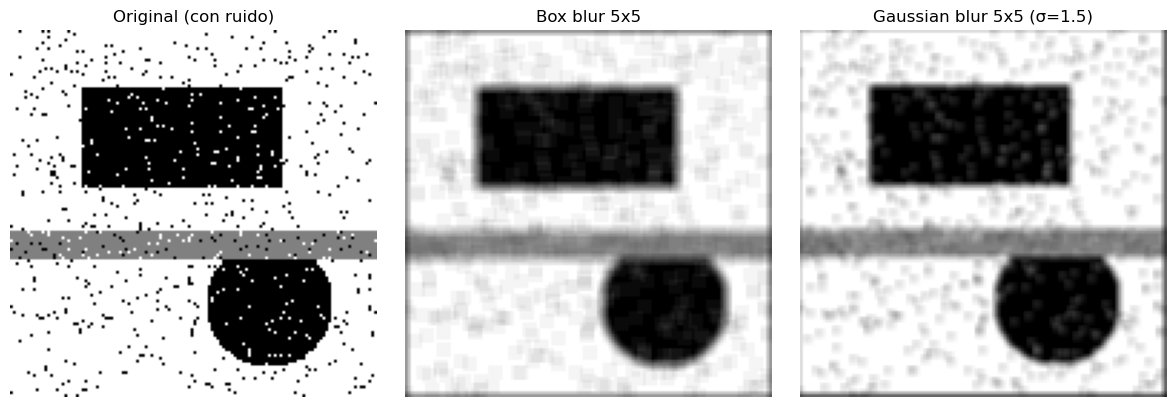

In [80]:
import os

# Evita el conflicto de múltiples runtimes OpenMP (MKL + libgomp) en Windows
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
import matplotlib.pyplot as plt

# Recuperar las imágenes como matrices 2D
orig = img_tensor.numpy().reshape(H, W)
box = img_box.numpy().reshape(H, W)
gauss = img_gauss.numpy().reshape(H, W)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, data, titulo in zip(
    axes,
    [orig, box, gauss],
    ["Original (con ruido)", "Box blur 5x5", "Gaussian blur 5x5 (σ=1.5)"],
):
    ax.imshow(data, cmap="gray", vmin=0, vmax=255)
    ax.set_title(titulo)
    ax.axis("off")

plt.tight_layout()
plt.show()

### 3. Procesamiento de señales con la Transformada de Fourier (FFT)

Otra área donde los tensores brillan es el **procesamiento de señales**. La **Transformada de Fourier** descompone una señal en el tiempo como una suma de senoides de distintas frecuencias, permitiéndonos ver **qué frecuencias la componen**.

##### La Transformada Discreta de Fourier (DFT)

Para una señal discreta $x_0, x_1, \dots, x_{N-1}$ de $N$ muestras, la DFT produce $N$ coeficientes complejos:

$$
X_k = \sum_{n=0}^{N-1} x_n \, e^{-\,i\, 2\pi \frac{k\,n}{N}}, \qquad k = 0, 1, \dots, N-1
$$

Cada coeficiente $X_k$ indica **cuánta** de la frecuencia $f_k = \dfrac{k \cdot f_s}{N}$ está presente en la señal, donde $f_s$ es la frecuencia de muestreo. La **FFT** (*Fast Fourier Transform*) es simplemente un algoritmo eficiente para calcular la DFT en $\mathcal{O}(N \log N)$ en lugar de $\mathcal{O}(N^2)$.

##### Magnitud y espectro

Como $X_k$ es un número complejo, normalmente analizamos su **magnitud**, que representa la amplitud de cada frecuencia:

$$
|X_k| = \sqrt{\operatorname{Re}(X_k)^2 + \operatorname{Im}(X_k)^2}
$$

Al graficar $|X_k|$ contra la frecuencia obtenemos el **espectro de frecuencias**. En TensorFlow usamos `tf.signal.fft` (para señales complejas) y las utilidades de `tf.signal`.

> **Idea del ejemplo:** crearemos una señal que es la suma de dos senoides (por ejemplo, 5 Hz y 40 Hz) más ruido; la FFT debe revelar **dos picos** claros en esas frecuencias, aunque a simple vista la señal en el tiempo se vea desordenada.


##### Generar una señal

Creamos una señal muestreada a $f_s = 500$ Hz durante 1 segundo, como suma de dos senoides:

$$
x(t) = A_1 \sin(2\pi f_1 t) + A_2 \sin(2\pi f_2 t) + \text{ruido}
$$

con $f_1 = 5$ Hz, $f_2 = 40$ Hz.

In [81]:
# Parámetros de muestreo
fs = 500          # frecuencia de muestreo (Hz)
T = 1.0           # duración (s)
N = int(fs * T)   # número de muestras

t = tf.linspace(0.0, T, N)  # vector de tiempo

# Señal: dos senoides (5 Hz y 40 Hz) + ruido
f1, f2 = 5.0, 40.0
A1, A2 = 1.0, 0.5
signal = (
    A1 * tf.sin(2.0 * np.pi * f1 * t)
    + A2 * tf.sin(2.0 * np.pi * f2 * t)
    + 0.3 * tf.random.normal([N], seed=0)
)

print("Muestras:", N, "| fs:", fs, "Hz")
print("Frecuencias reales en la señal:", f1, "Hz y", f2, "Hz")

Muestras: 500 | fs: 500 Hz
Frecuencias reales en la señal: 5.0 Hz y 40.0 Hz


##### calcular la FFT con `tf.signal.fft`

`tf.signal.fft` opera sobre tensores **complejos**, así que primero convertimos la señal a `complex64`. Luego calculamos la **magnitud** $|X_k|$ y el **vector de frecuencias** $f_k = \dfrac{k \cdot f_s}{N}$. Como la señal es real, el espectro es simétrico, por lo que basta con mostrar la **primera mitad** (frecuencias positivas hasta $f_s/2$, la frecuencia de Nyquist).

In [86]:
# tf.signal.fft requiere entrada compleja
signal_complex = tf.cast(signal, tf.complex64)
X = tf.signal.fft(signal_complex)
# Magnitud del espectro |X_k|
msgnitude = tf.abs(X)
# Vector de frecuencias f_k = k * fs / N
freqs = tf.range(N, dtype=tf.float32)*fs/N
freqs
# La señal es real -> el espectro es simétrico; nos quedamos con la mitad positiva
half = N//2
freqs_pos = freqs[:half]
magnitude_pos = msgnitude[:half]
# Frecuencia dominante (pico más alto)
pico = freqs_pos[tf.argmax(magnitude_pos)].numpy()
pico


np.float32(5.0)

##### visualizar la señal y su espectro

Arriba, la señal en el **dominio del tiempo** (se ve desordenada por el ruido y la mezcla de frecuencias). Abajo, su **espectro de frecuencias**: la FFT revela claramente los **dos picos** en 5 Hz y 40 Hz.

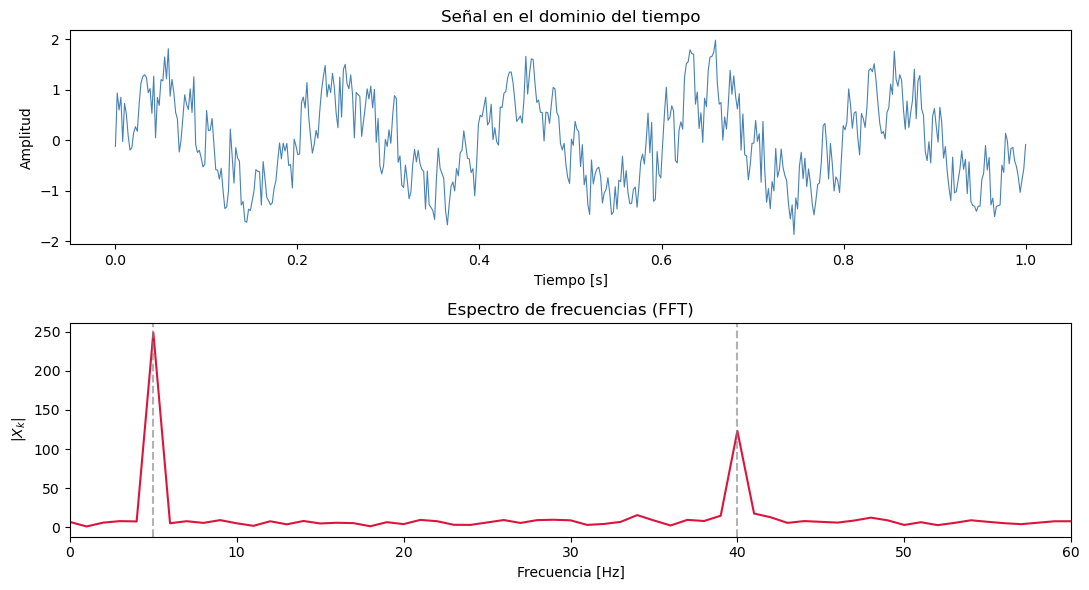

In [87]:
import os

# Evita el conflicto de múltiples runtimes OpenMP (MKL + libgomp) en Windows
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 6))

# Dominio del tiempo
ax1.plot(t.numpy(), signal.numpy(), color="steelblue", linewidth=0.8)
ax1.set_title("Señal en el dominio del tiempo")
ax1.set_xlabel("Tiempo [s]")
ax1.set_ylabel("Amplitud")

# Dominio de la frecuencia (espectro)
ax2.plot(freqs_pos.numpy(), magnitude_pos.numpy(), color="crimson")
ax2.set_title("Espectro de frecuencias (FFT)")
ax2.set_xlabel("Frecuencia [Hz]")
ax2.set_ylabel(r"$|X_k|$")
ax2.set_xlim(0, 60)
for f in (f1, f2):
    ax2.axvline(f, color="gray", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()